In [56]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


In [57]:
current_dir = os.getcwd()
training_set = pd.read_csv(r"./files/MNIST/kaggle csv format/mnist_train.csv")
testing_set = pd.read_csv(r"./files/MNIST/kaggle csv format/mnist_test.csv")
np.random.seed(100) # for reproducibility

In [58]:
#working through numpy
training_set = np.array(training_set)
m1, n1 = training_set.shape # m are pixels p/image, n are number of imgs (785, 60 000)
np.random.shuffle(training_set)

training_set = np.array(training_set)
training_set = training_set[:1000]
x_train = training_set[:, 1:].T
y_train = training_set[:, 0].reshape(1, -1)

testing_set = np.array(testing_set)
testing_set = testing_set[:2000]
x_test = testing_set[:, 1:].T
y_test = testing_set[:, 0].reshape(1, -1)

# normalize the data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [59]:
#define all functions
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))  # stability
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def ReLU(x):
    return x * (x>0)

def dReLU(x):
    return (x > 0).astype(float)

#cross entropy loss function
# y_true is one-hot encoded, y_pred is the output of the softmax layer
# y_true should be of shape (num_classes, num_samples)
def compute_loss(y_true, y_pred):
    m = y_true.shape[1]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    return loss

def one_hot(y, num_classes=10):
    m = y.shape[1]
    one_hot_y = np.zeros((num_classes, m))
    one_hot_y[y.astype(int), np.arange(m)] = 1
    return one_hot_y


In [60]:
def init_params(input_size, hidden_size, output_size):
    #He initialization for weights and biases
    w1 = np.random.randn(hidden_size, input_size) * np.sqrt(2. / input_size)
    b1 = np.zeros((hidden_size, 1))

    w2 = np.random.randn(output_size, hidden_size) * np.sqrt(2. / hidden_size)
    b2 = np.zeros((output_size, 1))

    param = {"w1": w1, "b1": b1, "w2": w2, "b2": b2}

    return param

In [61]:
np.random.seed(100)
param = init_params(784, 64, 10)

In [62]:
def forwardFeed(x, param):
    # retrieve parameters
    w1, b1 = param["w1"], param["b1"]
    w2, b2 = param["w2"], param["b2"]
    z1 = np.dot(w1, x) + b1
    a1 = ReLU(z1)
    z2 = np.dot(w2, a1) + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2

In [63]:
z1, a1, z2, a2 = forwardFeed(x_train, param)
print(a2.shape)

(10, 1000)


In [64]:
# backpropagation
def backwardFeed(x, y, z1, a1, z2, a2, param, learning_rate):
    m = x.shape[1]

    w2 = param["w2"]

    # Output layer gradient
    dz2 = a2 - y  # shape: (10, m)
    dw2 = (1 / m) * np.dot(dz2, a1.T)
    db2 = (1 / m) * np.sum(dz2, axis=1, keepdims=True)

    # Hidden layer gradient
    da1 = np.dot(w2.T, dz2)
    dz1 = da1 * dReLU(z1)
    dw1 = (1 / m) * np.dot(dz1, x.T)
    db1 = (1 / m) * np.sum(dz1, axis=1, keepdims=True)

    # Update weights
    param["w1"] -= learning_rate * dw1
    param["b1"] -= learning_rate * db1
    param["w2"] -= learning_rate * dw2
    param["b2"] -= learning_rate * db2

    return param

In [65]:
# accuracy function
def get_accuracy(predictions, labels):
    pred_labels = np.argmax(predictions, axis=0)
    true_labels = labels.flatten()
    return np.mean(pred_labels == true_labels)

In [66]:
#training loop
epochs = 1000
learning_rate = 0.001

# One-hot encode the labels
y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    # Forward pass
    z1, a1, z2, a2 = forwardFeed(x_train, param)
    
    # Loss
    loss = compute_loss(y_train_oh, a2)
    acc = get_accuracy(a2, y_train)
    
    # Backward pass and parameter update
    param = backwardFeed(x_train, y_train_oh, z1, a1, z2, a2, param, learning_rate)

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}: Loss = {loss:.4f}, Accuracy = {acc*100:.2f}%")
    
    train_losses.append(loss)
    train_accuracies.append(acc)

Epoch 0: Loss = 2.4872, Accuracy = 3.50%
Epoch 10: Loss = 2.4701, Accuracy = 3.50%
Epoch 20: Loss = 2.4537, Accuracy = 3.90%
Epoch 30: Loss = 2.4380, Accuracy = 4.10%
Epoch 40: Loss = 2.4230, Accuracy = 4.40%
Epoch 50: Loss = 2.4085, Accuracy = 5.00%
Epoch 60: Loss = 2.3947, Accuracy = 5.50%
Epoch 70: Loss = 2.3813, Accuracy = 6.20%
Epoch 80: Loss = 2.3683, Accuracy = 7.00%
Epoch 90: Loss = 2.3557, Accuracy = 7.60%
Epoch 100: Loss = 2.3435, Accuracy = 8.30%
Epoch 110: Loss = 2.3317, Accuracy = 8.60%
Epoch 120: Loss = 2.3202, Accuracy = 9.50%
Epoch 130: Loss = 2.3089, Accuracy = 10.30%
Epoch 140: Loss = 2.2979, Accuracy = 10.70%
Epoch 150: Loss = 2.2871, Accuracy = 11.90%
Epoch 160: Loss = 2.2764, Accuracy = 12.50%
Epoch 170: Loss = 2.2660, Accuracy = 12.80%
Epoch 180: Loss = 2.2557, Accuracy = 13.70%
Epoch 190: Loss = 2.2456, Accuracy = 14.50%
Epoch 200: Loss = 2.2357, Accuracy = 15.40%
Epoch 210: Loss = 2.2259, Accuracy = 15.90%
Epoch 220: Loss = 2.2164, Accuracy = 16.40%
Epoch 230: L

Test Accuracy: 53.45%


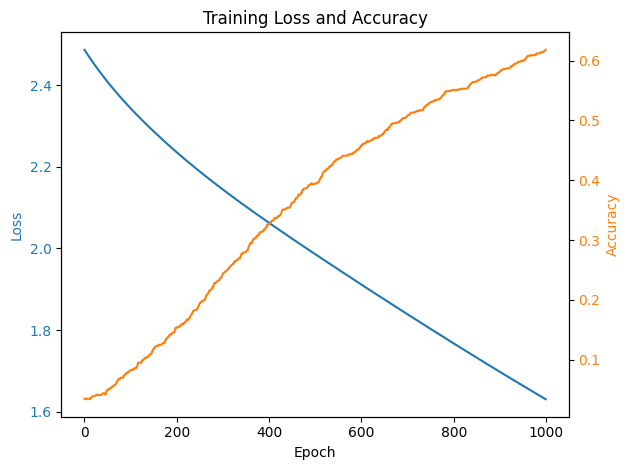

In [67]:
_, _, _, test_preds = forwardFeed(x_test, param)
test_acc = get_accuracy(test_preds, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Plotting the training loss and accuracy
fig, ax1 = plt.subplots()

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:blue')
ax1.plot(train_losses, color='tab:blue', label='Loss')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:orange')
ax2.plot(train_accuracies, color='tab:orange', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Training Loss and Accuracy")
fig.tight_layout()
plt.show()